# Tarification automobile : comprendre et modéliser la gravité

**Notre rôle : estimer le montant attendu sachant qu’un sinistre survient.** Le modèle de fréquence est développé séparément par notre partenaire.

$$g(x)=E[S\mid S>0,X=x], \qquad \text{prime pure}(x)=p(x)\times g(x).$$

Un montant prédit de 2 000 € ne constitue donc pas une prime de 2 000 €. Avec une probabilité de 5 %, la prime pure serait de 100 €.

**Périmètre :** aucun modèle de fréquence, aucune soumission Kaggle automatique. Tout le code métier est contenu dans ce notebook. Les CSV produits sont des résultats destinés au partenaire.

## 1. Environnement et reproductibilité

Nous utilisons pandas/numpy pour les données, matplotlib pour les figures et scikit-learn pour les pipelines et modèles. Une graine fixe rend la séparation et les modèles reproductibles. Limiter les threads évite de saturer la machine. Les versions affichées permettent d’expliquer une éventuelle différence entre deux exécutions.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
from pathlib import Path
import sys, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import GammaRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_gamma_deviance
from sklearn.inspection import permutation_importance
from threadpoolctl import threadpool_limits
threadpool_limits(limits=2)
SEED = 42
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
pd.set_option('display.max_columns', 40)
print({'Python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__, 'sklearn': sklearn.__version__})
# Trouver les données sans dépendre d’un chemin absolu propre à une machine.
candidates = [Path.cwd(), Path.cwd() / 'TD-Tarification-automobile-par-Machine-Learning']
ROOT = next((p for p in candidates if (p / 'Data/train.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Exécuter depuis la racine du dépôt ou son dossier parent.')
OUTPUT = ROOT / 'output' / 'gravite'
print('Racine du projet :', ROOT)

/home/cytech/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


{'Python': '3.12.3', 'pandas': '3.0.6', 'numpy': '2.5.3', 'sklearn': '1.9.1'}
Racine du projet : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning


## 2. Que représentent train.csv et test.csv ?

`train.csv` contient les caractéristiques connues et les résultats observés ; il sert à apprendre et à évaluer localement. `test.csv` contient les prospects à prédire, sans résultats observés : il ne permet donc pas de mesurer une erreur.

Une ligne décrit un **contrat associé à un véhicule**, pas nécessairement un client unique. Plusieurs contrats peuvent appartenir au même client. Le champ `index` sera conservé pour l’alignement des prédictions, mais jamais utilisé comme prédicteur. Le nom `nombre_sinistres` pourrait suggérer un comptage ; nous vérifions ses valeurs réelles au lieu de supposer qu’il représente une fréquence annuelle.

Nous lisons le code géographique comme du texte pour préserver les zéros initiaux. Sans dictionnaire de données, nous ne supposons pas que `code_postal` est effectivement un code postal plutôt qu’un code de commune.

In [2]:
train = pd.read_csv(ROOT / 'Data/train.csv', dtype={'code_postal': str})
test = pd.read_csv(ROOT / 'Data/test.csv', dtype={'code_postal': str})
TARGET = 'montant_sinistre'
CLAIM = 'nombre_sinistres'
print('Dimensions train :', train.shape, '| test :', test.shape)
display(train.head(3), test.head(3))
only_train = sorted(set(train) - set(test))
only_test = sorted(set(test) - set(train))
print('Colonnes uniquement dans train :', only_train)
print('Colonnes uniquement dans test :', only_test)
assert {TARGET, CLAIM, 'id_client', 'id_vehicule', 'id_contrat'} == set(only_train)
assert not only_test
assert train['index'].is_unique and test['index'].is_unique
assert set(train['index']).isdisjoint(set(test['index']))
print('Plages index :', (train['index'].min(), train['index'].max()), (test['index'].min(), test['index'].max()))
print('Doublons de contrats :', train.id_contrat.duplicated().sum())
print('Lignes supplémentaires pour des clients déjà présents :', train.id_client.duplicated().sum())
print('Doublons exacts train/test :', train.duplicated().sum(), test.duplicated().sum())

Dimensions train : (50000, 33) | test : (50000, 28)


,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,utilisation,code_postal,conducteur2,age_conducteur1,age_conducteur2,sex_conducteur1,sex_conducteur2,anciennete_permis1,anciennete_permis2,anciennete_vehicule,cylindre_vehicule,din_vehicule,essence_vehicule,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,0,A00000001,V01,A00000001-V01,0.5,Maxi,29,9,Biannual,No,Retired,36233,No,85,0,M,NaN,62,0,10.0,1587,98,Gasoline,PEUGEOT,306,10,9,182,Tourism,20700,1210,0,0.0
1,1,A00000002,V01,A00000002-V01,0.5,Maxi,3,1,Biannual,No,Retired,92073,No,69,0,M,NaN,39,0,4.0,2149,170,Diesel,MERCEDES BENZ,C220,4,2,229,Tourism,34250,1510,0,0.0
2,2,A00000003,V01,A00000003-V01,0.5,Maxi,2,2,Yearly,No,WorkPrivate,92026,No,37,0,M,NaN,18,0,11.0,1991,150,Gasoline,BMW,Z3,12,11,210,Tourism,28661,1270,0,0.0


,index,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,utilisation,code_postal,conducteur2,age_conducteur1,age_conducteur2,sex_conducteur1,sex_conducteur2,anciennete_permis1,anciennete_permis2,anciennete_vehicule,cylindre_vehicule,din_vehicule,essence_vehicule,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule
0,50000,0.58,Maxi,1,1,Yearly,No,Retired,28388,No,66,0,F,NaN,34,0,16.0,1239,55,Gasoline,RENAULT,CLIO,16,15,150,Tourism,10321,830
1,50001,0.50,Median2,2,2,Yearly,No,Retired,19123,No,68,0,M,NaN,48,0,15.0,2155,96,Diesel,MERCEDES BENZ,C220,16,12,175,Tourism,24652,1400
2,50002,0.76,Maxi,10,2,Biannual,No,WorkPrivate,77183,No,43,0,M,NaN,22,0,2.0,1598,90,Diesel,VOLKSWAGEN,POLO,2,1,180,Tourism,16280,1082


Colonnes uniquement dans train : ['id_client', 'id_contrat', 'id_vehicule', 'montant_sinistre', 'nombre_sinistres']
Colonnes uniquement dans test : []
Plages index : (0, 49999) (50000, 99999)
Doublons de contrats : 0
Lignes supplémentaires pour des clients déjà présents : 4215


Doublons exacts train/test : 0 0


### Dictionnaire de lecture et disponibilité

- **Cibles :** `nombre_sinistres` permet de sélectionner les sinistrés ; `montant_sinistre` est la cible de régression. Ces deux colonnes sont interdites en entrée du modèle.
- **Identifiants :** `index`, `id_client`, `id_vehicule`, `id_contrat` servent à repérer ou regrouper les lignes. Les trois derniers sont absents du test et ne peuvent pas servir à prédire.
- **Contrat :** `bonus`, `type_contrat`, `duree_contrat`, `anciennete_info`, `freq_paiement`, `paiement`, `utilisation` décrivent la relation ou l’usage. Les unités des durées et le sens exact de `paiement` doivent être confirmés.
- **Conducteurs :** `conducteur2`, âges, sexes, anciennetés de permis. Les zéros du second conducteur peuvent signifier son absence.
- **Véhicule :** ancienneté, cylindrée, puissance (`din_vehicule`), énergie, marque, modèle, dates/anciennetés de commercialisation, vitesse, type, prix et poids. Les unités et codages doivent être confirmés avant une interprétation métier précise.
- **Géographie :** `code_postal`, catégorie à forte cardinalité.

**Risque de fuite temporelle :** être présent dans le test ne prouve pas qu’un champ soit disponible avant le sinistre. Nous conservons les caractéristiques contractuelles communes sous cette hypothèse, à confirmer avec le fournisseur des données. Nous ne convertissons pas `duree_contrat` en exposition annuelle : l’horizon et les unités ne sont pas documentés.

**Sexe :** les deux colonnes sont auditées mais exclues des modèles par choix métier prudent, cohérent avec le point soulevé dans l’énoncé. Les autres variables peuvent néanmoins porter des informations corrélées ; leur retrait ne constitue pas une garantie complète d’équité.

In [3]:
common = [c for c in test if c != 'index']
audit = pd.DataFrame({
    'type_train': train.dtypes.astype(str),
    'type_test': test.dtypes.astype(str),
    'uniques_train': train.nunique(),
    'manquants_train_%': train.isna().mean().mul(100),
    'manquants_test_%': test.isna().mean().mul(100),
})
display(audit.round(3))
display(train.select_dtypes('number').describe(percentiles=[.01, .5, .99]).T.round(2))
quality = []
for name, df in [('train', train), ('test', test)]:
    quality.append({
        'fichier': name,
        'poids_zero': (df.poids_vehicule == 0).sum(),
        'cylindree_zero': (df.cylindre_vehicule == 0).sum(),
        'permis1_superieur_age': (df.anciennete_permis1 > df.age_conducteur1).sum(),
        'permis2_superieur_age': ((df.conducteur2 == 'Yes') & (df.anciennete_permis2 > df.age_conducteur2)).sum(),
        'sexe2_absent_sans_conducteur2': ((df.conducteur2 == 'No') & df.sex_conducteur2.isna()).sum(),
        'sexe2_absent_avec_conducteur2': ((df.conducteur2 == 'Yes') & df.sex_conducteur2.isna()).sum(),
    })
display(pd.DataFrame(quality).set_index('fichier'))

,type_train,type_test,uniques_train,manquants_train_%,manquants_test_%
age_conducteur1,int64,int64,83,0.000,0.000
age_conducteur2,int64,int64,81,0.000,0.000
anciennete_info,int64,int64,25,0.000,0.000
anciennete_permis1,int64,int64,79,0.000,0.000
anciennete_permis2,int64,int64,71,0.000,0.000
anciennete_vehicule,float64,float64,63,0.002,0.000
bonus,float64,float64,73,0.000,0.000
code_postal,str,str,12790,0.000,0.000
conducteur2,str,str,2,0.000,0.000
cylindre_vehicule,int64,int64,532,0.000,0.000


,count,mean,std,min,1%,50%,99%,max
index,50000.0,24999.50,14433.90,0.0,499.99,24999.5,49499.01,49999.00
bonus,50000.0,0.54,0.10,0.5,0.50,0.5,0.95,2.16
duree_contrat,50000.0,11.09,8.57,1.0,1.00,9.0,31.00,41.00
anciennete_info,50000.0,2.73,2.35,1.0,1.00,2.0,12.00,25.00
age_conducteur1,50000.0,54.65,14.87,19.0,24.00,54.0,86.00,101.00
age_conducteur2,50000.0,15.57,23.99,0.0,0.00,0.0,78.00,99.00
anciennete_permis1,50000.0,32.44,13.47,1.0,4.00,32.0,61.00,111.00
anciennete_permis2,50000.0,9.14,17.06,0.0,0.00,0.0,59.00,111.00
anciennete_vehicule,49999.0,9.53,7.01,1.0,1.00,8.0,33.00,65.00
cylindre_vehicule,50000.0,1647.80,463.65,0.0,652.00,1587.0,2993.00,6997.00


,poids_zero,cylindree_zero,permis1_superieur_age,permis2_superieur_age,sexe2_absent_sans_conducteur2,sexe2_absent_avec_conducteur2
fichier,,,,,,
train,1883,3,12,397,33406,0
test,1861,2,14,371,33408,0


### Politique de traitement des anomalies

Les poids et cylindrées à zéro sont remplacés par des valeurs manquantes, puis imputés dans la pipeline ; ce choix reste une hypothèse faute de dictionnaire. Une ancienneté de permis supérieure à l’âge est également mise à manquant. Nous n’imposons pas de seuil d’âge légal spécifique au permis, dont l’unité et la catégorie ne sont pas confirmées.

Pour le second conducteur, les zéros sont conservés quand `conducteur2 == 'No'` : ils représentent une absence structurelle, déjà indiquée par cette variable. Les valeurs extrêmes plausibles (véhicules coûteux, conducteurs âgés, gros sinistres) sont conservées. Ces règles sont fixes et indépendantes de la cible ; les statistiques d’imputation sont apprises seulement sur l’ensemble d’apprentissage.

## 3. Les deux fichiers décrivent-ils des populations comparables ?

Nous comparons les caractéristiques, jamais des cibles inconnues du test. Pour les variables numériques, le déplacement standardisé de la moyenne mesure la différence en unités d’écart-type du train. Pour les catégories, la distance de variation totale vaut 0 pour des distributions identiques et 1 pour des distributions disjointes.

Ces indicateurs sont descriptifs : ils ne prouvent ni stabilité temporelle ni différence significative. Les modalités absentes des **sinistrés d’apprentissage** seront également contrôlées plus loin, car ce sous-ensemble est beaucoup plus petit que le train complet.

,moyenne_train,moyenne_test,mediane_train,mediane_test,deplacement_standardise
bonus,0.538,0.537,0.5,0.5,-0.012
din_vehicule,91.548,91.237,87.0,87.0,-0.009
prix_vehicule,18095.562,18021.821,16250.0,16200.0,-0.008
cylindre_vehicule,1647.796,1643.971,1587.0,1587.0,-0.008
anciennete_permis1,32.445,32.535,32.0,33.0,0.007
debut_vente_vehicule,11.628,11.679,10.0,10.0,0.007
fin_vente_vehicule,8.653,8.693,7.0,7.0,0.006
anciennete_vehicule,9.531,9.573,8.0,8.0,0.006
anciennete_info,2.727,2.740,2.0,2.0,0.006
poids_vehicule,1129.088,1127.327,1130.0,1125.0,-0.005


,variable,distance_variation_totale,modalites_nouvelles_test,lignes_test_modalite_inconnue_%
4,code_postal,0.305,5004,14.964
10,modele_vehicule,0.045,137,0.412
9,marque_vehicule,0.011,12,0.038
1,freq_paiement,0.005,0,0.000
0,type_contrat,0.004,0,0.000
3,utilisation,0.003,0,0.000
7,sex_conducteur2,0.002,0,0.000
8,essence_vehicule,0.002,0,0.000
11,type_vehicule,0.002,0,0.000
6,sex_conducteur1,0.000,0,0.000


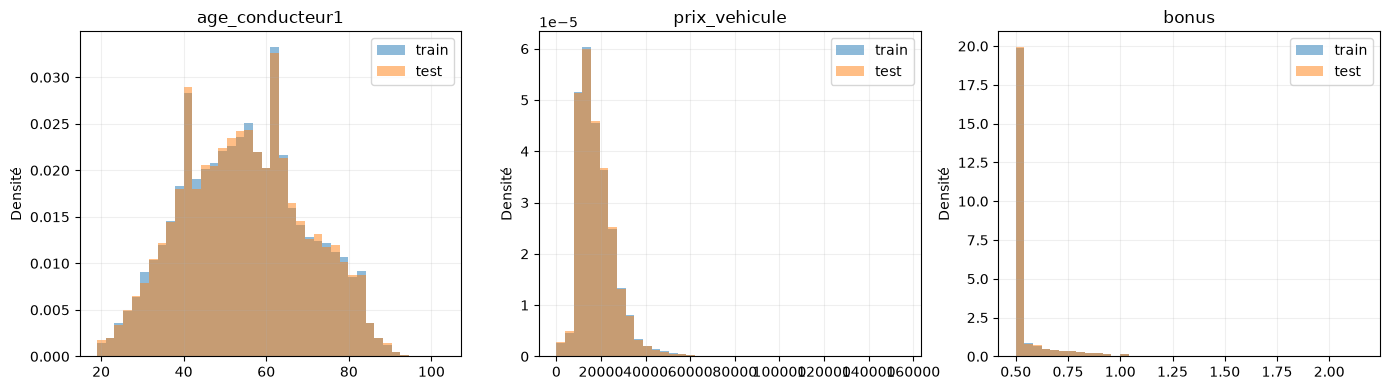

In [4]:
cat_raw = [c for c in common if not pd.api.types.is_numeric_dtype(train[c])]
num_raw = [c for c in common if c not in cat_raw]
shift_num = pd.DataFrame({
    'moyenne_train': train[num_raw].mean(), 'moyenne_test': test[num_raw].mean(),
    'mediane_train': train[num_raw].median(), 'mediane_test': test[num_raw].median(),
    'deplacement_standardise': (test[num_raw].mean()-train[num_raw].mean()) / train[num_raw].std().replace(0, np.nan)
})
display(shift_num.reindex(shift_num.deplacement_standardise.abs().sort_values(ascending=False).index).round(3))
shift_cat = []
for col in cat_raw:
    a = train[col].fillna('__ABSENT__').value_counts(normalize=True)
    b = test[col].fillna('__ABSENT__').value_counts(normalize=True)
    keys = a.index.union(b.index)
    shift_cat.append({'variable': col, 'distance_variation_totale': .5 * (a.reindex(keys, fill_value=0)-b.reindex(keys, fill_value=0)).abs().sum(),
                      'modalites_nouvelles_test': len(set(b.index)-set(a.index)),
                      'lignes_test_modalite_inconnue_%': 100 * (~test[col].fillna('__ABSENT__').isin(a.index)).mean()})
display(pd.DataFrame(shift_cat).sort_values('distance_variation_totale', ascending=False).round(3))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['age_conducteur1', 'prix_vehicule', 'bonus']):
    bins = np.histogram_bin_edges(pd.concat([train[col], test[col]]).dropna(), bins=40)
    ax.hist(train[col].dropna(), bins=bins, density=True, alpha=.5, label='train')
    ax.hist(test[col].dropna(), bins=bins, density=True, alpha=.5, label='test')
    ax.set(title=col, ylabel='Densité'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Comprendre notre cible : uniquement les contrats sinistrés

Avant de filtrer, vérifions que les zéros de coût correspondent à l’absence de sinistre. Le filtre d’apprentissage sera `nombre_sinistres > 0`. Il ne sera jamais utilisé sur le test : notre modèle doit prédire un montant conditionnel pour **tous** les prospects, même ceux qui n’auront probablement pas de sinistre.

La moyenne de gravité est calculée sur les sinistrés ; la moyenne sur tout le portefeuille est une moyenne de coût, qui inclut la fréquence. Les confondre ferait intervenir deux fois la probabilité de sinistre lors du calcul de la prime.

,effectif
nombre_sinistres,
0,47083
1,2917


,montant_euros
count,2917.00
mean,1771.84
std,1463.95
min,600.60
1%,612.51
25%,959.97
50%,1236.00
75%,2169.10
90%,3336.74
95%,4355.26


Taux de contrats sinistrés : 5.83%
Gravité moyenne : 1,771.84 € ; médiane : 1,236.00 €
Coût moyen de tout le portefeuille : 103.37 €
Part du coût portée par les montants >= P99 : 5.96%
Montants les plus répétés (hypothèse de forfaits ou de codage, à confirmer) :


,effectif
montant_sinistre,
1236.00,333
1010.41,128
2683.76,44
618.00,31
1442.87,30
1240.89,18
2453.28,17
2323.95,12
3288.46,8


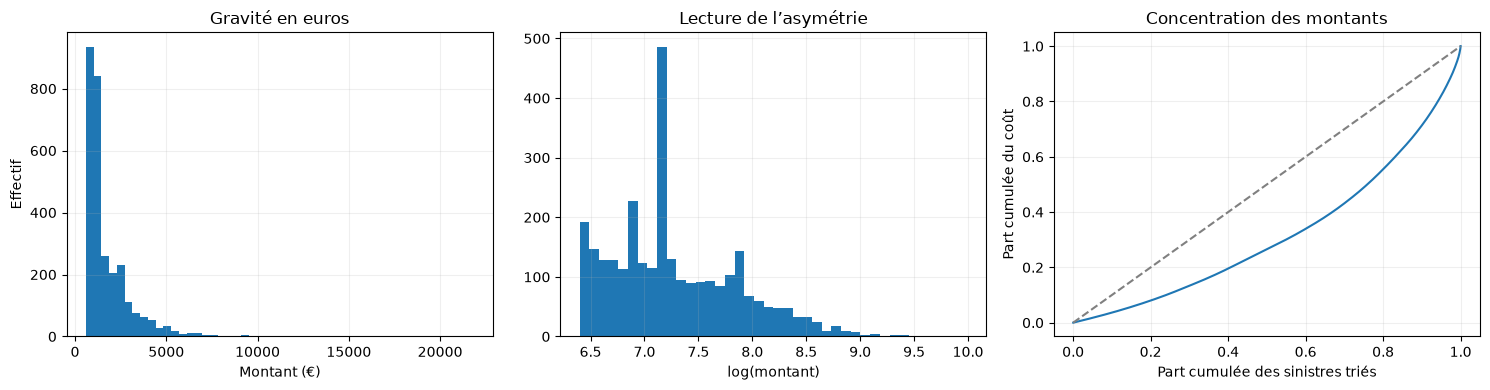

In [5]:
assert train[[CLAIM, TARGET]].notna().all().all()
assert np.isfinite(train[TARGET]).all() and train[TARGET].ge(0).all()
assert train.loc[train[CLAIM] == 0, TARGET].eq(0).all()
assert train.loc[train[CLAIM] > 0, TARGET].gt(0).all()
claims = train.loc[train[CLAIM] > 0].copy()
display(train[CLAIM].value_counts().sort_index().rename_axis('nombre_sinistres').to_frame('effectif'))
display(claims[TARGET].describe(percentiles=[.01, .25, .5, .75, .9, .95, .99]).to_frame('montant_euros').round(2))
threshold = claims[TARGET].quantile(.99)
print(f'Taux de contrats sinistrés : {len(claims)/len(train):.2%}')
print(f'Gravité moyenne : {claims[TARGET].mean():,.2f} € ; médiane : {claims[TARGET].median():,.2f} €')
print(f'Coût moyen de tout le portefeuille : {train[TARGET].mean():,.2f} €')
print(f'Part du coût portée par les montants >= P99 : {claims.loc[claims[TARGET]>=threshold, TARGET].sum()/claims[TARGET].sum():.2%}')
print('Montants les plus répétés (hypothèse de forfaits ou de codage, à confirmer) :')
display(claims[TARGET].value_counts().head(10).to_frame('effectif'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(claims[TARGET], bins=50); axes[0].set(xlabel='Montant (€)', ylabel='Effectif', title='Gravité en euros')
axes[1].hist(np.log(claims[TARGET]), bins=40); axes[1].set(xlabel='log(montant)', title='Lecture de l’asymétrie')
sorted_y = np.sort(claims[TARGET].to_numpy())
axes[2].plot(np.arange(1,len(sorted_y)+1)/len(sorted_y), np.cumsum(sorted_y)/sorted_y.sum())
axes[2].plot([0,1],[0,1], '--', color='grey'); axes[2].set(xlabel='Part cumulée des sinistres triés', ylabel='Part cumulée du coût', title='Concentration des montants')
plt.tight_layout(); plt.show()

### Pourquoi privilégier le RMSE en euros ?

Le critère quadratique vise une **espérance conditionnelle** : c’est la quantité dont nous avons besoin pour multiplier par la probabilité. Nous utilisons le RMSE comme métrique principale de gravité, le MAE pour une lecture complémentaire, et le biais moyen pour repérer une sous-estimation globale. La déviance Gamma apporte un diagnostic relatif aux montants positifs.

L’énoncé nomme à la fois MSE et RMSE ; ils produisent le même classement sur les mêmes observations. Toutefois, **le RMSE de gravité n’est pas le score Kaggle** : ce dernier mesure l’erreur de prime sur tous les contrats, et dépend aussi des probabilités du partenaire.

Le logarithme ci-dessus sert seulement à visualiser. Nous ne choisissons pas une régression logarithmique pour cette première version : exponentier une prédiction moyenne de log-montant ne restitue généralement pas la moyenne en euros. La régression Gamma à lien log conserve une cible en euros et ne nécessite pas cette retransformation.

## 5. Construire une validation qui respecte les clients

Nous réservons 20 % des **clients** à une validation finale, à partir du portefeuille complet, puis sélectionnons les sinistrés dans chaque partition. Cette règle permet au partenaire de reprendre exactement les mêmes contrats pour sa validation de fréquence.

Les statistiques globales précédentes sont descriptives. Les relations cible/features, les paramètres appris et les comparaisons de modèles ci-dessous utilisent uniquement la partition d’apprentissage. La validation finale ne sert pas au choix des hyperparamètres.

Il n’existe pas de date d’observation explicite permettant une validation temporelle. Le regroupement par client limite une fuite concrète, mais ne simule pas nécessairement un futur changement de portefeuille. Les identifiants clients sont absents du test : un éventuel recouvrement de clients train/test ne peut pas y être vérifié.

In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=.2, random_state=SEED)
pos_dev, pos_val = next(splitter.split(train, groups=train.id_client))
dev_all = train.iloc[pos_dev].copy()
val_all = train.iloc[pos_val].copy()
assert set(dev_all.id_client).isdisjoint(set(val_all.id_client))
dev = dev_all.loc[dev_all[CLAIM] > 0].copy()
val = val_all.loc[val_all[CLAIM] > 0].copy()
display(pd.DataFrame([
    {'partition': name, 'contrats': len(all_), 'clients': all_.id_client.nunique(), 'sinistres': len(part), 'taux_sinistre': len(part)/len(all_)}
    for name, all_, part in [('apprentissage', dev_all, dev), ('validation', val_all, val)]
]))
manifest = train[['index', 'id_client']].rename(columns={'index': 'id'}).copy()
manifest['partition'] = np.where(train.index.isin(dev_all.index), 'apprentissage', 'validation')
print('Ce manifeste sera exporté pour partager la séparation avec le partenaire.')

,partition,contrats,clients,sinistres,taux_sinistre
0,apprentissage,40013,36628,2352,0.058781
1,validation,9987,9157,565,0.056574


Ce manifeste sera exporté pour partager la séparation avec le partenaire.


## 6. Relations entre caractéristiques et gravité — apprentissage seulement

Nous affichons les effectifs avec les moyennes et médianes : une moyenne sur quelques sinistres est instable. Les associations sont descriptives et ne prouvent pas une causalité. Les contrats les plus couvrants peuvent, par exemple, concerner des clients ou véhicules différents.

Pour les variables numériques, la corrélation de Spearman décrit une association monotone sans supposer une relation linéaire. Pour le prix et l’âge, des groupes de quantiles rendent la relation plus lisible. Nous ne créons pas de règle de tarification manuelle à partir de ces graphiques.

**type_contrat**

,count,mean,median
type_contrat,,,
Maxi,1944,1838.20,1294.26
Median1,111,1580.86,1236.00
Mini,59,1444.55,1236.00
Median2,238,1335.40,1235.89


**utilisation**

,count,mean,median
utilisation,,,
Professional,224,1935.10,1247.06
WorkPrivate,1495,1782.03,1236.00
Retired,628,1668.06,1236.00
AllTrips,5,1368.31,1236.00


**essence_vehicule**

,count,mean,median
essence_vehicule,,,
Diesel,1461,1771.06,1236.00
Gasoline,886,1760.01,1236.00
Hybrid,5,1019.20,852.21


**type_vehicule**

,count,mean,median
type_vehicule,,,
Tourism,2188,1777.87,1236.0
Commercial,164,1597.55,1236.0


**conducteur2**

,count,mean,median
conducteur2,,,
Yes,854,1772.34,1236.0
No,1498,1761.29,1236.0


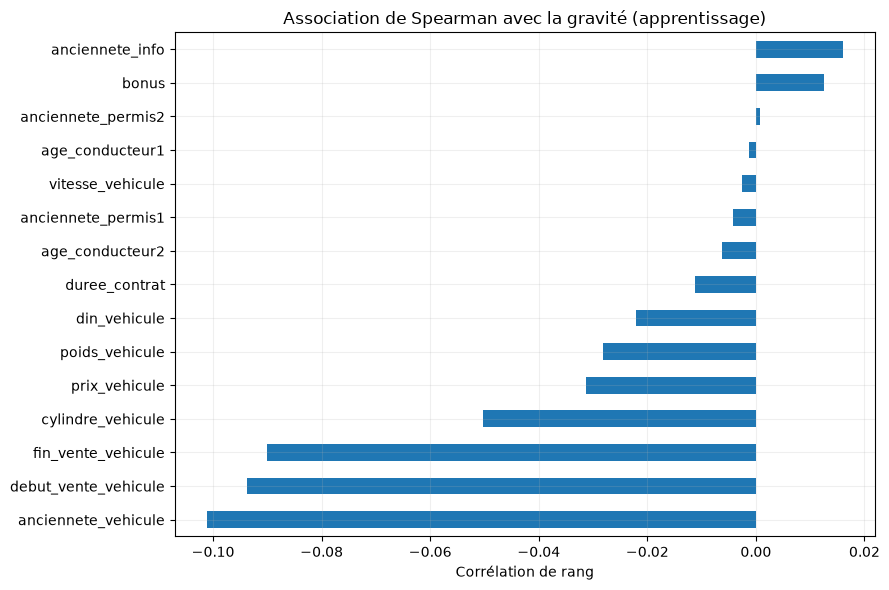

**prix_vehicule, groupes de quantiles**

,count,mean,median
prix_vehicule,,,
"(7088.999, 12850.0]",475,1688.14,1236.00
"(12850.0, 16700.0]",467,1755.37,1236.00
"(16700.0, 20894.4]",469,1862.97,1240.89
"(20894.4, 26550.0]",471,1767.51,1236.00
"(26550.0, 89500.0]",470,1753.48,1236.00


**age_conducteur1, groupes de quantiles**

,count,mean,median
age_conducteur1,,,
"(18.999, 41.0]",485,1814.24,1236.0
"(41.0, 51.0]",502,1906.01,1236.0
"(51.0, 59.0]",464,1703.45,1236.0
"(59.0, 68.0]",446,1716.96,1236.0
"(68.0, 93.0]",455,1668.36,1236.0


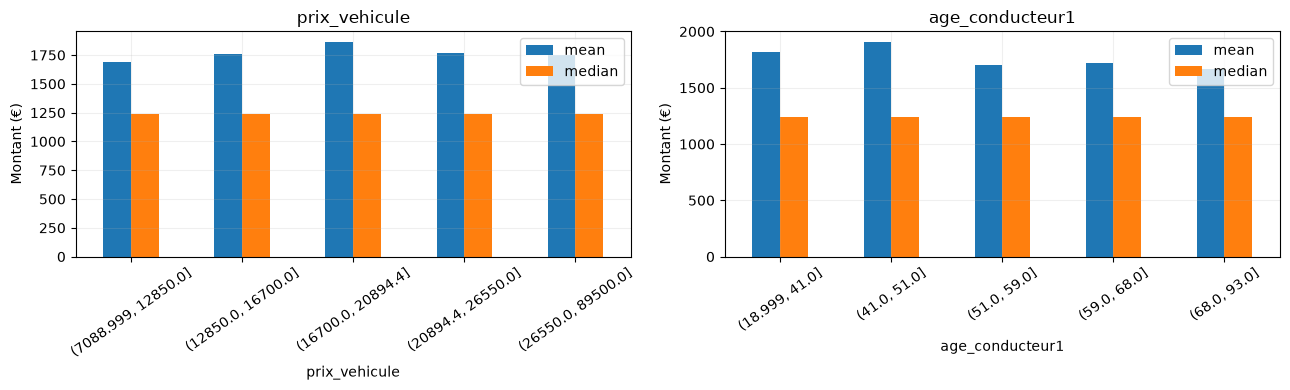

In [7]:
for col in ['type_contrat', 'utilisation', 'essence_vehicule', 'type_vehicule', 'conducteur2']:
    summary = dev.groupby(col, dropna=False)[TARGET].agg(['count','mean','median']).sort_values('mean', ascending=False)
    display(Markdown(f'**{col}**'), summary.round(2))
correlations = dev[num_raw + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET).sort_values()
correlations.plot.barh(figsize=(9,6), title='Association de Spearman avec la gravité (apprentissage)')
plt.xlabel('Corrélation de rang'); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, col in zip(axes, ['prix_vehicule', 'age_conducteur1']):
    bins = pd.qcut(dev[col], q=5, duplicates='drop')
    summary = dev.groupby(bins, observed=True)[TARGET].agg(['count','mean','median'])
    display(Markdown(f'**{col}, groupes de quantiles**'), summary.round(2))
    summary[['mean','median']].plot.bar(ax=ax, rot=35, title=col)
    ax.set_ylabel('Montant (€)')
plt.tight_layout(); plt.show()

## 7. Préparation réutilisable et catégories inconnues

Nous utilisons uniquement les colonnes disponibles dans les deux fichiers. Les catégories sont encodées en indicatrices ; celles comptant moins de 20 observations **dans le sous-ensemble ajusté** sont regroupées. Cela limite le nombre de paramètres pour les marques, modèles et codes géographiques.

`handle_unknown='infrequent_if_exist'` permet d’appliquer le modèle à une nouvelle modalité : elle rejoint le groupe rare s’il existe, sinon ses indicatrices valent zéro. Les imputations et regroupements sont réappris dans chaque pli de validation croisée. Le test n’intervient dans aucun ajustement.

La standardisation aide la régression Gamma régularisée. Elle est inutile pour les arbres, qui reçoivent les variables numériques imputées à leur échelle initiale.

In [8]:
EXCLUDE = {'index', 'sex_conducteur1', 'sex_conducteur2'}
FEATURES = [c for c in test if c not in EXCLUDE]
CAT = [c for c in FEATURES if not pd.api.types.is_numeric_dtype(train[c])]
NUM = [c for c in FEATURES if c not in CAT]
def prepare_features(df):
    x = df.loc[:, FEATURES].copy()
    for col in ['poids_vehicule', 'cylindre_vehicule']:
        x[col] = x[col].mask(x[col] <= 0)
    for k in [1,2]:
        age, licence = f'age_conducteur{k}', f'anciennete_permis{k}'
        x[licence] = x[licence].mask(x[licence] > x[age])
    for col in CAT:
        x[col] = x[col].astype(object).where(x[col].notna(), np.nan)
    return x

def preprocessing(scale=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median', add_indicator=True))]
    if scale:
        numeric_steps.append(('scale', StandardScaler()))
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='__MANQUANT__')),
        ('encoder', OneHotEncoder(min_frequency=20, handle_unknown='infrequent_if_exist', sparse_output=False))
    ])
    return ColumnTransformer([('num', Pipeline(numeric_steps), NUM), ('cat', categorical, CAT)], remainder='drop')
X_dev, X_val = prepare_features(dev), prepare_features(val)
y_dev, y_val = dev[TARGET], val[TARGET]
groups_dev = dev.id_client
assert TARGET not in FEATURES and CLAIM not in FEATURES
print('Prédicteurs retenus :', len(FEATURES), '| numériques :', len(NUM), '| catégoriels :', len(CAT))
unseen = pd.DataFrame([
    {'variable': c, 'test_inconnu_%': 100*(~test[c].fillna('__MANQUANT__').isin(dev[c].fillna('__MANQUANT__'))).mean()}
    for c in CAT
]).sort_values('test_inconnu_%', ascending=False)
display(unseen.round(2))

Prédicteurs retenus : 25 | numériques : 15 | catégoriels : 10


,variable,test_inconnu_%
4,code_postal,58.04
8,modele_vehicule,7.66
7,marque_vehicule,0.67
0,type_contrat,0.00
1,freq_paiement,0.00
2,paiement,0.00
5,conducteur2,0.00
3,utilisation,0.00
6,essence_vehicule,0.00
9,type_vehicule,0.00


## 8. Baselines et modèles candidats

1. **Moyenne constante :** référence principale pour une perte quadratique. Elle ignore les caractéristiques et prédit la gravité moyenne d’apprentissage.
2. **Médiane constante :** référence complémentaire, adaptée au MAE mais pas optimale pour le RMSE.
3. **Régression Gamma à lien logarithmique :** modèle positif, interprétable, adapté à une cible strictement positive. Le paramètre `alpha` contrôle la régularisation ; la perte Gamma n’est pas identique à la perte quadratique finale.
4. **Boosting d’arbres, perte quadratique :** capture des non-linéarités et interactions, avec complexité limitée vu le petit nombre de sinistrés.

Nous sélectionnons parmi ces candidats sur le **RMSE moyen de trois plis groupés par client**. Les baselines sont elles aussi réestimées dans chaque pli. Nous limitons la grille à sept configurations de modèles ajustables : mieux vaut une comparaison rigoureuse qu’une longue recherche sur peu de données. Aucun choix ne dépend du score Kaggle.

In [9]:
cv = list(GroupKFold(n_splits=3).split(X_dev, y_dev, groups=groups_dev))
for a, b in cv:
    assert set(groups_dev.iloc[a]).isdisjoint(set(groups_dev.iloc[b]))
candidates = {
    'Moyenne': (DummyRegressor(strategy='mean'), {}),
    'Mediane': (DummyRegressor(strategy='median'), {}),
    'Gamma': (Pipeline([('prep', preprocessing(scale=True)), ('model', GammaRegressor(max_iter=3000, tol=1e-5))]),
              {'model__alpha': [.1, 1., 10.]}),
    'Boosting': (Pipeline([('prep', preprocessing()), ('model', HistGradientBoostingRegressor(
        loss='squared_error', max_iter=200, learning_rate=.05, early_stopping=False, random_state=SEED))]),
        {'model__max_leaf_nodes': [7, 15], 'model__min_samples_leaf': [20, 50]})
}
searches = {}
rows = []
for name, (estimator, grid) in candidates.items():
    search = GridSearchCV(estimator, grid, cv=cv, scoring='neg_root_mean_squared_error',
                          n_jobs=1, return_train_score=True, error_score='raise')
    search.fit(X_dev, y_dev)
    searches[name] = search
    i = search.best_index_
    rows.append({'modele': name, 'RMSE_CV': -search.best_score_,
                 'ecart_type_CV': search.cv_results_['std_test_score'][i],
                 'RMSE_apprentissage_CV': -search.cv_results_['mean_train_score'][i],
                 'parametres': search.best_params_})
    print(name, 'terminé')
cv_results = pd.DataFrame(rows).set_index('modele').sort_values('RMSE_CV')
display(cv_results.round(2))
WINNER = cv_results.index[0]
selected = searches[WINNER].best_estimator_
print('Modèle retenu avant de consulter la validation finale :', WINNER)

Moyenne terminé
Mediane terminé


Gamma terminé


Boosting terminé


,RMSE_CV,ecart_type_CV,RMSE_apprentissage_CV,parametres
modele,,,,
Gamma,1492.80,153.80,1490.96,{'model__alpha': 1.0}
Moyenne,1501.71,157.53,1507.55,{}
Boosting,1517.35,142.90,1325.46,"{'model__max_leaf_nodes': 7, 'model__min_sampl..."
Mediane,1593.35,144.97,1598.14,{}


Modèle retenu avant de consulter la validation finale : Gamma


### Comment lire la comparaison ?

Un RMSE d’apprentissage faible avec un RMSE de validation croisée nettement plus élevé signale une possible suradaptation. L’écart-type entre plis renseigne sur la stabilité, mais n’est pas un intervalle de confiance indépendant : les plis partagent une partie de leurs données d’apprentissage.

Si la moyenne constante gagne, il faut l’accepter : les caractéristiques disponibles ou le nombre de sinistres peuvent ne pas permettre une meilleure estimation. Nous ne forçons pas le choix d’un modèle complexe.

## 9. Validation finale : performance en euros et diagnostic

Nous évaluons une fois les modèles retenus par validation croisée. Le gagnant reste celui choisi précédemment : consulter les autres scores de validation sert à diagnostiquer, pas à le remplacer discrètement.

Le biais est défini par `prédiction − observation` ; un biais négatif indique une sous-estimation. Le ratio des sommes concerne ici les **sinistrés** et ne mesure pas la rentabilité du portefeuille. Le RMSE officiel de prime nécessite les probabilités indépendantes du partenaire.

,RMSE,MAE,biais,ratio_sommes,deviance_Gamma
modele,,,,,
Moyenne,1253.606,935.352,-33.779,0.981,0.377
Mediane,1373.843,831.282,-563.080,0.687,0.537
Gamma,1248.780,924.480,-31.182,0.983,0.373
Boosting,1256.741,939.536,-13.391,0.993,0.380


**Modèle sélectionné : Gamma.** Gain de RMSE face à la moyenne sur cette validation : **0.38 %**. Un gain négatif signifie une dégradation sur cet échantillon.

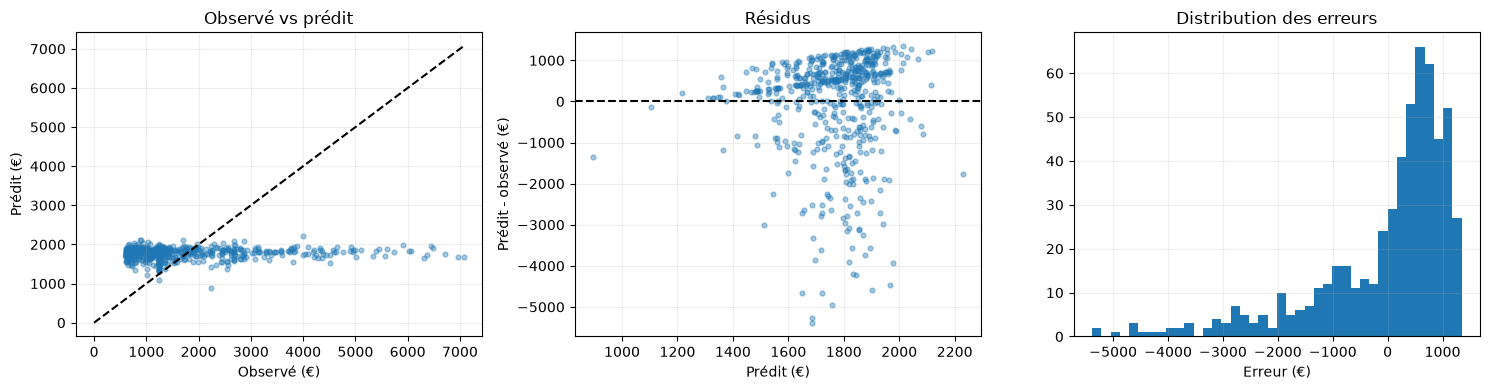

In [10]:
def positive_prediction(estimator, x):
    raw = np.asarray(estimator.predict(x), dtype=float)
    if not np.isfinite(raw).all():
        raise ValueError('Prédictions non finies')
    # Garde-fou documenté ; avec les modèles actuels et cibles positives, normalement inactif.
    return np.maximum(raw, np.finfo(float).eps)

def metrics(y, pred):
    return {'RMSE': root_mean_squared_error(y, pred), 'MAE': mean_absolute_error(y,pred),
            'biais': np.mean(pred-np.asarray(y)), 'ratio_sommes': np.sum(pred)/np.sum(y),
            'deviance_Gamma': mean_gamma_deviance(y,pred)}
validation_predictions = {}
val_rows = []
for name, search in searches.items():
    pred = positive_prediction(search.best_estimator_, X_val)
    validation_predictions[name] = pred
    val_rows.append({'modele': name, **metrics(y_val, pred)})
validation_results = pd.DataFrame(val_rows).set_index('modele')
display(validation_results.round(3))
pred_val = validation_predictions[WINNER]
base_rmse = validation_results.loc['Moyenne', 'RMSE']
gain = 100*(1-validation_results.loc[WINNER, 'RMSE']/base_rmse)
display(Markdown(f'**Modèle sélectionné : {WINNER}.** Gain de RMSE face à la moyenne sur cette validation : **{gain:.2f} %**. Un gain négatif signifie une dégradation sur cet échantillon.'))
fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].scatter(y_val, pred_val, alpha=.4, s=12)
lim = max(y_val.max(), pred_val.max())
axes[0].plot([0,lim],[0,lim], '--', color='black'); axes[0].set(xlabel='Observé (€)', ylabel='Prédit (€)', title='Observé vs prédit')
axes[1].scatter(pred_val, pred_val-y_val.to_numpy(), alpha=.4, s=12)
axes[1].axhline(0, color='black', linestyle='--'); axes[1].set(xlabel='Prédit (€)', ylabel='Prédit - observé (€)', title='Résidus')
axes[2].hist(pred_val-y_val.to_numpy(), bins=40); axes[2].set(xlabel='Erreur (€)', title='Distribution des erreurs')
plt.tight_layout(); plt.show()

### Sinistres coûteux et calibration des montants

Nous définissons le seuil des gros sinistres par le P90 **d’apprentissage**, puis appliquons ce seuil à la validation. Nous ne supprimons ni ne plafonnons les observations coûteuses : elles comptent fortement dans le critère officiel.

Un modèle d’espérance ne peut pas prévoir chaque accident exceptionnel. Une sous-estimation des observations les plus coûteuses n’implique donc pas à elle seule un modèle incohérent ; nous regardons aussi la calibration par groupes de prédictions. Les groupes de montants observés décrivent les erreurs a posteriori, pas une segmentation utilisable sur les prospects.

,n,RMSE,MAE,biais,ratio_sommes,deviance_Gamma,part_erreur_carree
segment,,,,,,,
Autres,494,755.648,665.508,356.179,1.253,0.249,0.32
Couteux (>=P90 apprentissage),71,2904.622,2726.343,-2726.343,0.398,1.240,0.68


Contrats avec les plus grandes erreurs :


,index,type_contrat,prix_vehicule,montant_sinistre,montant_pred,erreur,erreur_absolue,erreur_carree,segment_observe
14110,14110,Maxi,19950,7068.54,1685.37,-5383.17,5383.17,28978565.25,Couteux (>=P90 apprentissage)
15060,15060,Maxi,12678,6965.17,1685.42,-5279.75,5279.75,27875774.80,Couteux (>=P90 apprentissage)
38825,38825,Maxi,14500,6708.07,1759.12,-4948.95,4948.95,24492140.52,Couteux (>=P90 apprentissage)
24556,24556,Median2,14544,6304.41,1649.69,-4654.72,4654.72,21666381.09,Couteux (>=P90 apprentissage)
49718,49718,Maxi,31253,6372.04,1721.01,-4651.03,4651.03,21632037.28,Couteux (>=P90 apprentissage)
35201,35201,Maxi,14250,6484.17,1900.22,-4583.95,4583.95,21012554.27,Couteux (>=P90 apprentissage)
6565,6565,Maxi,33900,6443.23,1968.34,-4474.89,4474.89,20024666.24,Couteux (>=P90 apprentissage)
16776,16776,Maxi,21940,6064.03,1844.44,-4219.59,4219.59,17804945.05,Couteux (>=P90 apprentissage)
42134,42134,Maxi,25660,6019.26,1832.36,-4186.90,4186.90,17530164.71,Couteux (>=P90 apprentissage)
40457,40457,Maxi,16000,5915.10,1978.89,-3936.21,3936.21,15493763.18,Couteux (>=P90 apprentissage)


,n,observe,predit
groupe_predit,,,
"(895.558, 1655.154]",113,1533.13,1536.77
"(1655.154, 1759.179]",113,1932.86,1711.07
"(1759.179, 1827.264]",113,1853.75,1794.12
"(1827.264, 1884.344]",113,1915.22,1855.16
"(1884.344, 2228.35]",113,1760.45,1942.38


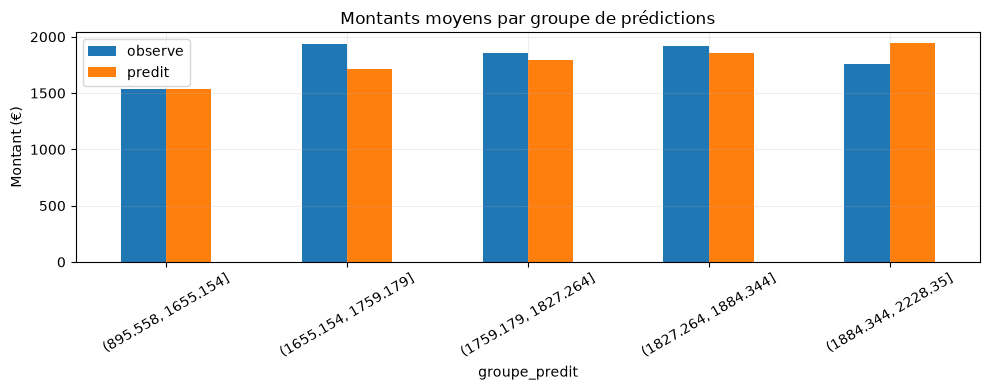

In [11]:
errors = val[['index', 'type_contrat', 'prix_vehicule', TARGET]].copy()
errors['montant_pred'] = pred_val
errors['erreur'] = pred_val-y_val.to_numpy()
errors['erreur_absolue'] = errors.erreur.abs()
errors['erreur_carree'] = errors.erreur**2
tail_cut = y_dev.quantile(.9)
errors['segment_observe'] = np.where(errors[TARGET]>=tail_cut, 'Couteux (>=P90 apprentissage)', 'Autres')
segments = []
for name, part in errors.groupby('segment_observe'):
    segments.append({'segment': name, 'n': len(part), **metrics(part[TARGET], part.montant_pred),
                     'part_erreur_carree': part.erreur_carree.sum()/errors.erreur_carree.sum()})
display(pd.DataFrame(segments).set_index('segment').round(3))
print('Contrats avec les plus grandes erreurs :')
display(errors.nlargest(10, 'erreur_absolue').round(2))
# rank(method='dense') préserve les égalités ; si prédiction constante, un seul groupe.
if pd.Series(pred_val).nunique() > 1:
    errors['groupe_predit'] = pd.qcut(errors.montant_pred, q=5, duplicates='drop')
else:
    errors['groupe_predit'] = 'Prediction constante'
calibration = errors.groupby('groupe_predit', observed=True).agg(n=(TARGET,'size'), observe=(TARGET,'mean'), predit=('montant_pred','mean'))
display(calibration.round(2))
calibration[['observe','predit']].plot.bar(rot=30, title='Montants moyens par groupe de prédictions')
plt.ylabel('Montant (€)'); plt.tight_layout(); plt.show()

## 10. Interpréter sans confondre association et causalité

L’importance par permutation mesure l’augmentation du RMSE lorsque l’on mélange une variable, en gardant le modèle fixe. Nous la calculons sur la validation, pour interprétation seulement : elle ne sert pas à refaire une sélection de variables ou de modèles sur cet ensemble.

Des caractéristiques corrélées peuvent se remplacer et diluer leur importance. Une importance négative n’est pas une preuve qu’une variable doit être supprimée ; elle peut venir de l’incertitude de l’échantillon. Si une baseline constante gagne, son absence de variables influentes est le résultat à expliquer.

,importance_RMSE,ecart_type
anciennete_permis1,2.09,0.80
type_contrat,0.92,0.78
duree_contrat,0.81,0.46
utilisation,0.31,0.14
modele_vehicule,0.29,0.12
vitesse_vehicule,0.25,0.08
essence_vehicule,0.21,0.22
paiement,0.09,0.06
age_conducteur1,0.07,0.05
cylindre_vehicule,0.05,0.09


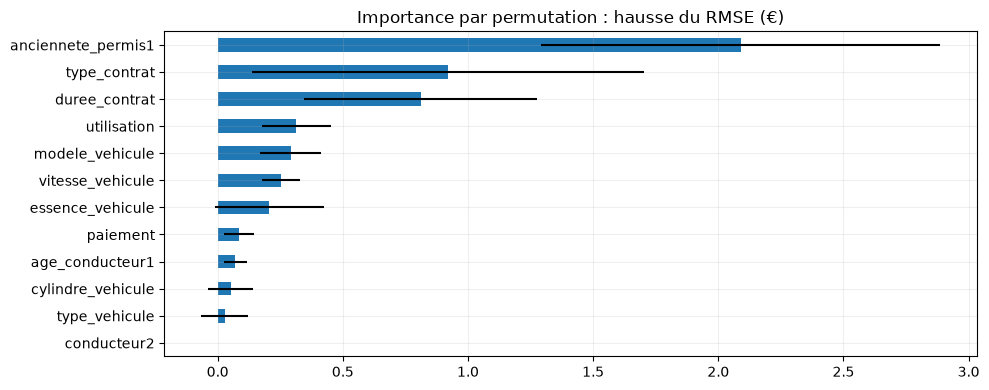

In [12]:
if WINNER in ['Moyenne', 'Mediane']:
    importances = pd.DataFrame(columns=['importance_RMSE', 'ecart_type'])
    print('Le modèle sélectionné est constant : aucune importance de variable à interpréter.')
else:
    perm = permutation_importance(selected, X_val, y_val, scoring='neg_root_mean_squared_error', n_repeats=5, random_state=SEED, n_jobs=1)
    importances = pd.DataFrame({'importance_RMSE': perm.importances_mean, 'ecart_type': perm.importances_std}, index=FEATURES).sort_values('importance_RMSE', ascending=False)
    display(importances.head(15).round(2))
    top = importances.head(12).sort_values('importance_RMSE')
    top.importance_RMSE.plot.barh(xerr=top.ecart_type, title='Importance par permutation : hausse du RMSE (€)')
    plt.tight_layout(); plt.show()

## 11. Réentraîner et prédire la gravité des prospects

Après l’évaluation, nous gardons la même configuration et ajustons le modèle sur **tous les sinistrés du train**. Nous produisons une gravité pour chaque ligne du test, en conservant l’identifiant `index` dans une colonne d’échange nommée `id`.

Nous contrôlons les valeurs finies et positives, le nombre de lignes, l’unicité des identifiants et l’ordre. L’index du test commence après celui du train : nous ne le remplaçons pas par une numérotation arbitraire de 0 à 49 999. Le format d’identifiant de la soumission finale devra être confirmé avec le fichier officiel `sample_submission`, absent du dépôt.

,id,montant_pred
0,50000,1594.489540
1,50001,1527.436345
2,50002,1958.880928
3,50003,1755.574901
4,50004,1577.284431


count    50000.00
mean      1695.07
std        174.78
min        825.11
25%       1587.30
50%       1721.53
75%       1825.30
max       2251.93
Name: montant_pred, dtype: float64

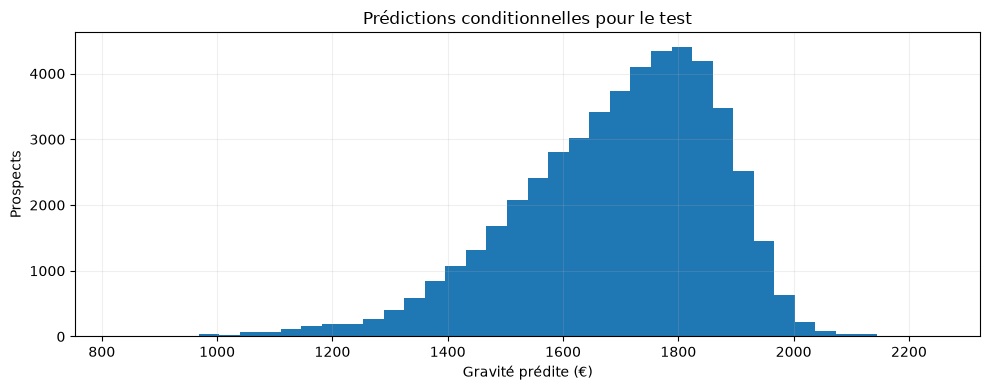

Résultats exportés dans : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning/output/gravite


In [13]:
final_model = clone(selected)
final_model.fit(prepare_features(claims), claims[TARGET])
pred_test = positive_prediction(final_model, prepare_features(test))
gravity_test = pd.DataFrame({'id': test['index'].to_numpy(), 'montant_pred': pred_test})
assert len(gravity_test) == len(test)
assert gravity_test.id.is_unique
assert np.array_equal(gravity_test.id.to_numpy(), test['index'].to_numpy())
assert np.isfinite(gravity_test.montant_pred).all() and gravity_test.montant_pred.gt(0).all()
display(gravity_test.head(), gravity_test.montant_pred.describe().round(2))
plt.hist(gravity_test.montant_pred, bins=40)
plt.xlabel('Gravité prédite (€)'); plt.ylabel('Prospects'); plt.title('Prédictions conditionnelles pour le test')
plt.tight_layout(); plt.show()
# Pour la validation, conserver le modèle ajusté uniquement sur l’apprentissage.
gravity_validation = pd.DataFrame({
    'id': val_all['index'].to_numpy(),
    'montant_pred': positive_prediction(selected, prepare_features(val_all))
})
validation_reference = val_all[['index', CLAIM, TARGET]].rename(columns={'index':'id'}).copy()
OUTPUT.mkdir(parents=True, exist_ok=True)
gravity_test.to_csv(OUTPUT / 'predictions_gravite_test.csv', index=False)
gravity_validation.to_csv(OUTPUT / 'predictions_gravite_validation.csv', index=False)
manifest.to_csv(OUTPUT / 'partition_clients.csv', index=False)
validation_reference.to_csv(OUTPUT / 'reference_validation.csv', index=False)
cv_results.to_csv(OUTPUT / 'comparaison_cv.csv')
validation_results.to_csv(OUTPUT / 'scores_validation.csv')
print('Résultats exportés dans :', OUTPUT)

## 12. Interface avec le modèle de fréquence

Le partenaire doit reprendre `partition_clients.csv` : sa validation doit contenir les mêmes clients, et son modèle de fréquence ne doit pas avoir appris leurs résultats. Pour le test, il réentraîne sa fréquence sur son train complet.

Les fichiers de gravité contiennent `id,montant_pred`. Les fichiers de fréquence attendus par la fonction ci-dessous contiennent `id,proba_pred` avec des probabilités comprises entre 0 et 1. La jointure se fait sur l’identifiant, **jamais sur la position des lignes**. La fonction refuse les identifiants absents, dupliqués ou supplémentaires.

Aucun modèle de fréquence n’est entraîné ici. Nous définissons uniquement une interface d’assemblage, sans l’exécuter faute de probabilités. Après assemblage de validation, calculer le RMSE sur tous les contrats et comparer la somme des primes aux coûts observés. Une prime pure n’intègre pas les frais, marges ou taxes : ce ratio seul ne démontre pas la rentabilité réelle.

In [14]:
def assemble_prime(gravity, frequency):
    required = {'id', 'proba_pred'}
    if not required.issubset(frequency.columns):
        raise ValueError('Fréquence attendue : colonnes id et proba_pred')
    if not gravity.id.is_unique or not frequency.id.is_unique:
        raise ValueError('Identifiants dupliqués')
    if gravity.id.isna().any() or frequency.id.isna().any():
        raise ValueError('Identifiants manquants')
    if set(gravity.id) != set(frequency.id):
        raise ValueError('Les ensembles d’identifiants diffèrent')
    if not np.isfinite(frequency.proba_pred).all() or not frequency.proba_pred.between(0,1).all():
        raise ValueError('Probabilités non finies ou hors de [0,1]')
    joined = gravity.merge(frequency[['id','proba_pred']], on='id', how='left', validate='one_to_one', sort=False)
    if not np.isfinite(joined.montant_pred).all() or (joined.montant_pred<=0).any():
        raise ValueError('Montants non positifs ou non finis')
    return pd.DataFrame({'id': joined.id, 'pred': joined.montant_pred * joined.proba_pred})

# Exemple d’utilisation lorsque les probabilités indépendantes seront disponibles :
# frequency_val = pd.read_csv('predictions_frequence_validation.csv')
# premium_val = assemble_prime(gravity_validation, frequency_val)
# evaluation = premium_val.merge(validation_reference, on='id', validate='one_to_one')
# print('RMSE prime :', root_mean_squared_error(evaluation[TARGET], evaluation.pred))
# print('Ratio primes / coûts :', evaluation.pred.sum()/evaluation[TARGET].sum())
# Pour le test : vérifier d’abord les identifiants du sample_submission officiel.
# submission = assemble_prime(gravity_test, pd.read_csv('predictions_frequence_test.csv'))
# submission.to_csv(OUTPUT / 'submission.csv', index=False)

## 13. Conclusion et limites pour la soutenance

Cette cellule rédige une synthèse à partir des résultats réellement obtenus. Les conclusions devront être comprises et discutées par l’équipe, pas seulement lues.

Les principales limites sont le faible nombre de sinistrés, les modalités rares, l’incertitude du dictionnaire de données, l’absence de dates d’observation et la sensibilité aux grands sinistres. Aucun intervalle d’incertitude sur les scores n’est estimé ici. La validation unique ne garantit pas le classement Kaggle.

Les pistes suivantes, à décider après cette première analyse, seraient une validation groupée répétée, une confirmation des variables disponibles à la tarification, et une comparaison de nouvelles familles de modèles. Toute itération utilisant les diagnostics de la validation actuelle devra être signalée ; celle-ci ne serait alors plus une évaluation indépendante.

In [15]:
score = validation_results.loc[WINNER]
tail_name = 'Couteux (>=P90 apprentissage)'
tail = errors[errors.segment_observe == tail_name]
summary = f"""### Synthèse calculée
- **Données :** {len(train):,} contrats d’apprentissage, {len(test):,} prospects et {len(claims):,} sinistrés pour apprendre la gravité.
- **Cible :** moyenne de {claims[TARGET].mean():,.2f} € contre médiane de {claims[TARGET].median():,.2f} € ; l’asymétrie justifie l’étude des gros sinistres.
- **Validation :** {len(dev):,} sinistrés d’apprentissage et {len(val):,} de validation, sans client partagé.
- **Choix par validation croisée :** {WINNER}, RMSE CV de {cv_results.loc[WINNER,'RMSE_CV']:,.2f} €.
- **Validation finale :** RMSE {score.RMSE:,.2f} €, MAE {score.MAE:,.2f} €, biais {score.biais:,.2f} €, ratio des sommes {score.ratio_sommes:.3f}.
- **Comparaison à la moyenne :** gain de RMSE {gain:.2f} % sur cette validation.
- **Sinistres coûteux :** {len(tail)} observations au-dessus du P90 d’apprentissage ({tail_cut:,.2f} €), RMSE {root_mean_squared_error(tail[TARGET],tail.montant_pred):,.2f} €.
- **Livraison :** prédictions positives pour chaque prospect, jointure par identifiant avec le partenaire ; aucun score officiel de prime annoncé sans ses probabilités.
"""
display(Markdown(summary))
assert set(dev.id_client).isdisjoint(set(val.id_client))
assert len(gravity_validation) == len(val_all)
assert set(gravity_validation.id) == set(validation_reference.id)
print('Contrôles finaux : OK')

### Synthèse calculée
- **Données :** 50,000 contrats d’apprentissage, 50,000 prospects et 2,917 sinistrés pour apprendre la gravité.
- **Cible :** moyenne de 1,771.84 € contre médiane de 1,236.00 € ; l’asymétrie justifie l’étude des gros sinistres.
- **Validation :** 2,352 sinistrés d’apprentissage et 565 de validation, sans client partagé.
- **Choix par validation croisée :** Gamma, RMSE CV de 1,492.80 €.
- **Validation finale :** RMSE 1,248.78 €, MAE 924.48 €, biais -31.18 €, ratio des sommes 0.983.
- **Comparaison à la moyenne :** gain de RMSE 0.38 % sur cette validation.
- **Sinistres coûteux :** 71 observations au-dessus du P90 d’apprentissage (3,279.88 €), RMSE 2,904.62 €.
- **Livraison :** prédictions positives pour chaque prospect, jointure par identifiant avec le partenaire ; aucun score officiel de prime annoncé sans ses probabilités.


Contrôles finaux : OK
